# Sales Analysis — AAL (Australia)

## Project statement

**AAL**, established in 2000, is a well-known brand in Australia, particularly recognized for its clothing business. It has opened branches in various states, metropolises, and tier-1 and tier-2 cities across the country.

The brand caters to all age groups, from kids to the elderly.

Currently experiencing a surge in business, AAL is actively pursuing expansion opportunities. To facilitate informed investment decisions, the **CEO** has assigned the responsibility to the **head of AAL’s sales and marketing (S&M) department**. The specific tasks include:

1. **Identify the states that are generating the highest revenues.**
2. **Develop sales programs for states with lower revenues.**

The head of sales and marketing has requested your assistance with this task.

---

### Analysis brief

Analyze the **sales data of the company for the fourth quarter in Australia**, examining it on a **state-by-state** basis. Provide **insights** to assist the company in making **data-driven decisions** for the upcoming year.

**Data file:** `AusApparalSales4thQrt2020.csv` (fourth-quarter sales data for Australia).

## Required work (as a data scientist)

Perform the following on the enclosed data:

### 1. Data wrangling

- **a.** Ensure that the data is clean and free from any missing or incorrect entries.
  - Inspect the data manually to identify missing or incorrect information using **`isna()`** and **`notna()`**.
- **b.** Based on your knowledge of data analytics, include your **recommendations** for treating missing and incorrect data (dropping null values or filling them).
- **c.** Choose a suitable data wrangling technique—either **data standardization** or **normalization**. Execute the **preferred normalization** method and present the resulting data. *(Normalization is the preferred approach for this problem.)*
- **d.** Share your **insights** regarding the application of **`GroupBy()`** for either data chunking or merging, and offer a **recommendation** based on your analysis.

### 2. Data analysis

- **a.** Perform **descriptive statistical analysis** on the data in the **Sales** and **Unit** columns. Use techniques such as **mean, median, mode, and standard deviation**.
- **b.** Identify the **group with the highest sales** and the **group with the lowest sales** based on the data provided.
- **c.** Identify the **group with the highest and lowest sales** based on the data provided.
- **d.** Generate **weekly, monthly, and quarterly** reports to document and present the results of the analysis conducted.

*(Use suitable libraries such as **NumPy**, **Pandas**, and **SciPy** for performing the analysis.)*

### 3. Data visualization

- **a.** Use suitable data visualization libraries to construct a **dashboard** for the head of sales and marketing. The dashboard should encompass:
  - **State-wise sales analysis** for different demographic groups (**kids, women, men, and seniors**).
  - **Group-wise sales analysis** (Kids, Women, Men, and Seniors) across various **states**.
  - **Time-of-the-day analysis:** Identify **peak and off-peak** sales periods to facilitate strategic planning for S&M teams (e.g. hyper-personalization, Next Best Offers).
- **b.** Ensure the visualization is **clear and accessible** for effective decision-making by the head of S&M.

The dashboard must contain **daily, weekly, monthly, and quarterly** charts.

*(Any visualization library can be used; **Seaborn** is preferred given statistical analysis.)*

- **c.** Include your **recommendation** and indicate **why** you are choosing the recommended visualization package.

### 4. Report generation

- **a.** Use **JupyterLab Notebook** for generating reports, integrating code with graphs and plots.
- **b.** Use **Markdown** in suitable places while presenting your report.
- **c.** Use suitable graphs, plots, and analysis reports in the report, along with **recommendations**. Different aspects of analysis may require different graphs and plots.
  - Use a **box plot** for descriptive statistics.
  - Use **Seaborn distribution plot(s)** for other statistical plotting.

---

*Work through these steps in the cells below.*

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [2]:
# Load Data
df = pd.read_csv("AusApparalSales4thQrt2020.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [6]:
# Data Wrangling
# Check for missing values
df.isnull().sum()
# Fill numeric columns with median
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)
# Check for duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)


C:\Users\apoor\AppData\Local\Temp\ipykernel_38792\1945296304.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\apoor\AppData\Local\Temp\ipykernel_38792\1945296304.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [9]:
# Normalize Data FOR Sales- Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Sales_Normalized']] = scaler.fit_transform(df[['Sales']])
df[['Units_Normalized']] = scaler.fit_transform(df[['Unit']])

df.head()

,Date,Time,State,Group,Unit,Sales,Sales_Normalized,Units_Normalized
0,1-Oct-2020,Morning,WA,Kids,8,20000,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,8,20000,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,4,10000,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,15,37500,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,3,7500,0.015873,0.015873


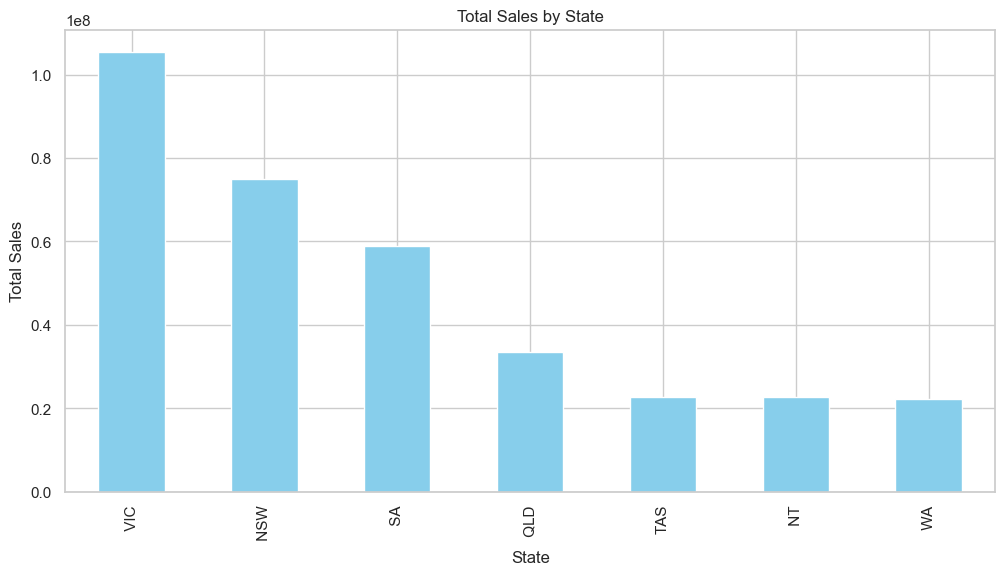

In [10]:
# GET Group By Sales by Product Category
# State-wise aggregation
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

state_sales.plot(kind='bar', color='skyblue')
plt.title('Total Sales by State')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.show()

In [17]:
# Data Analysis
df[['Sales', 'Unit']].describe()

# Mean, Median, Mode, Std
print("Mean:\n", df[['Sales','Unit']].mean())
print("Median:\n", df[['Sales','Unit']].median())
print("Mode:\n", df[['Sales','Unit']].mode().iloc[0])
print("Standard Deviation:\n", df[['Sales','Unit']].std())

Mean:
 Sales    45013.558201
Unit        18.005423
dtype: float64
Median:
 Sales    35000.0
Unit        14.0
dtype: float64
Mode:
 Sales    22500
Unit         9
Name: 0, dtype: int64
Standard Deviation:
 Sales    32253.506944
Unit        12.901403
dtype: float64


In [18]:
# Highest and Lowest Sales by State
highest_sales_state = state_sales.idxmax()
lowest_sales_state = state_sales.idxmin()
print(f"Highest Sales State: {highest_sales_state} with sales of {state_sales.max()}")
print(f"Lowest Sales State: {lowest_sales_state} with sales of {state_sales.min()}")

Highest Sales State:  VIC with sales of 105565000
Lowest Sales State:  WA with sales of 22152500


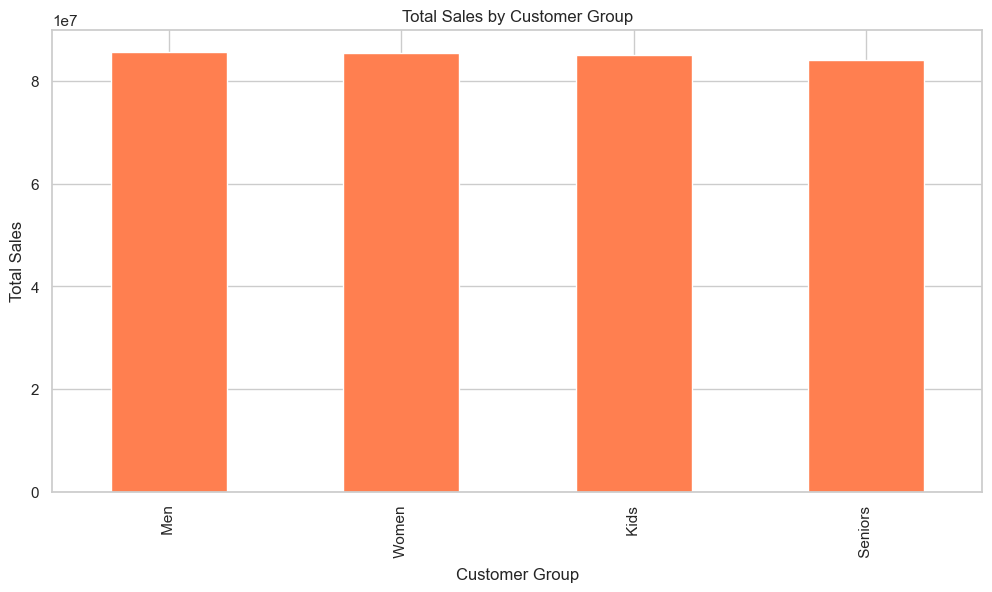

In [31]:
# Group-wise Sales for Kids, Women, Men, Seniors
group_sales = df.groupby('Group')['Sales'].sum().sort_values(ascending=False)
group_sales.plot(kind='bar', color='coral')
plt.title('Total Sales by Customer Group')
plt.xlabel('Customer Group')
plt.ylabel('Total Sales')
plt.show()

### Group-wise Sales Analysis
This chart shows total sales for each customer group, helping identify the strongest segments and those needing further attention.

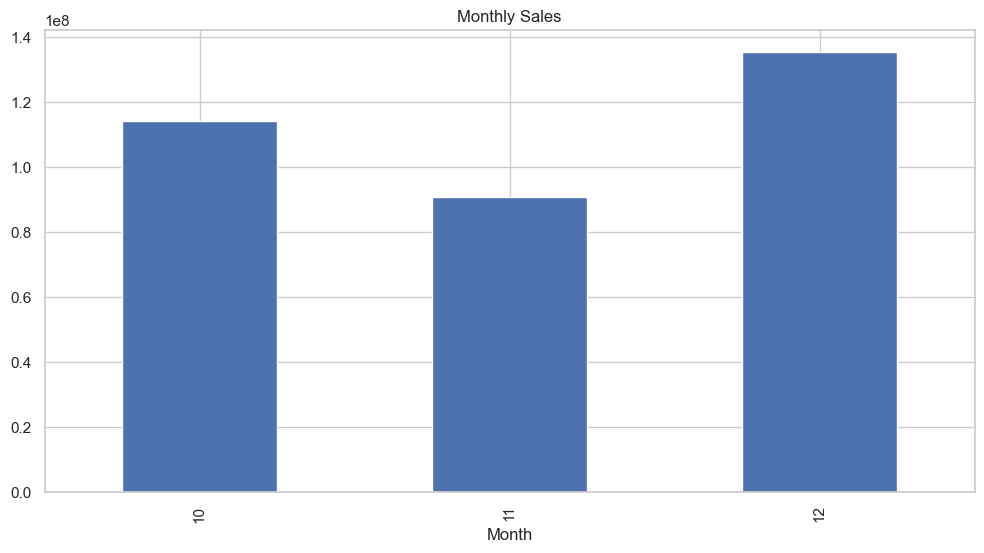

In [23]:
# Convert 'Date' to datetime and extract Week, Month, Quarter
df['Date'] = pd.to_datetime(df['Date'])

df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

# Sales by Month
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot(kind='bar')
plt.title("Monthly Sales")
plt.show()

### Monthly Sales Trend
This bar chart summarizes monthly revenue and helps spot seasonal trends across the fourth quarter.

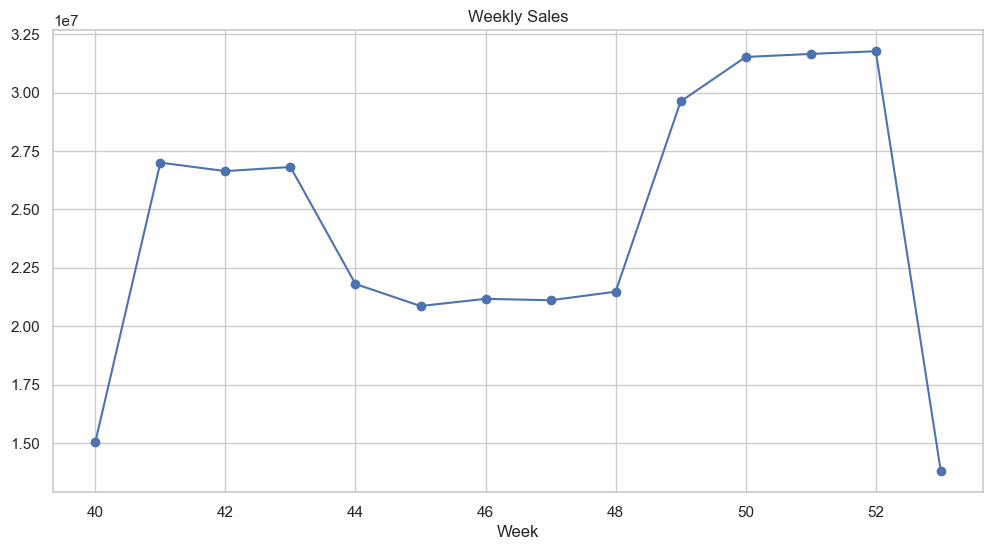

In [25]:
# weekly sales
weekly_sales = df.groupby('Week')['Sales'].sum()
weekly_sales.plot(kind='line', marker='o')
plt.title("Weekly Sales")
plt.show()

### Weekly Sales Trend
This line chart shows how sales vary from week to week, making it easier to identify short-term performance shifts.

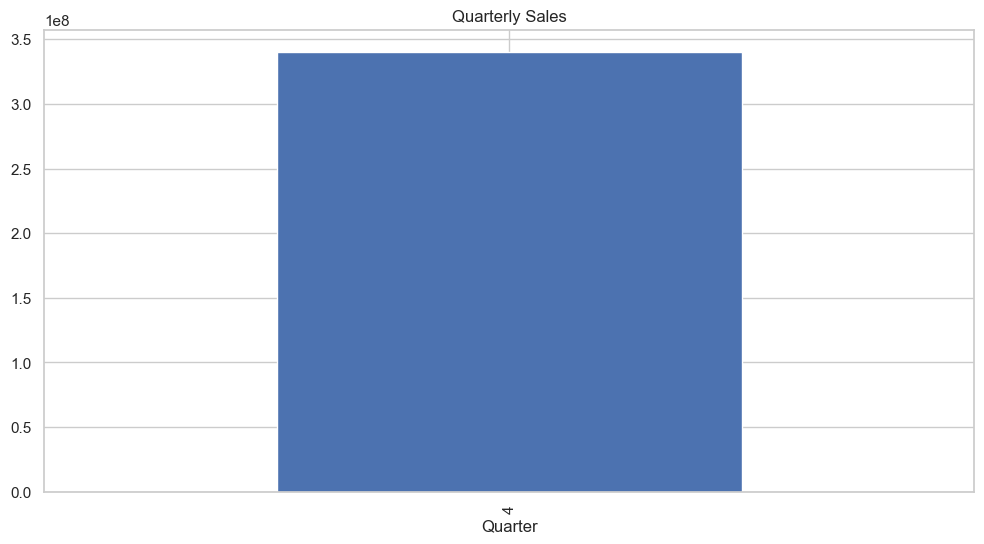

In [27]:
# Quarterly Sales
quarterly_sales = df.groupby('Quarter')['Sales'].sum()
quarterly_sales.plot(kind='bar')
plt.title("Quarterly Sales")
plt.show()

### Quarterly Sales Summary
This chart highlights overall quarterly revenue and supports high-level business review.

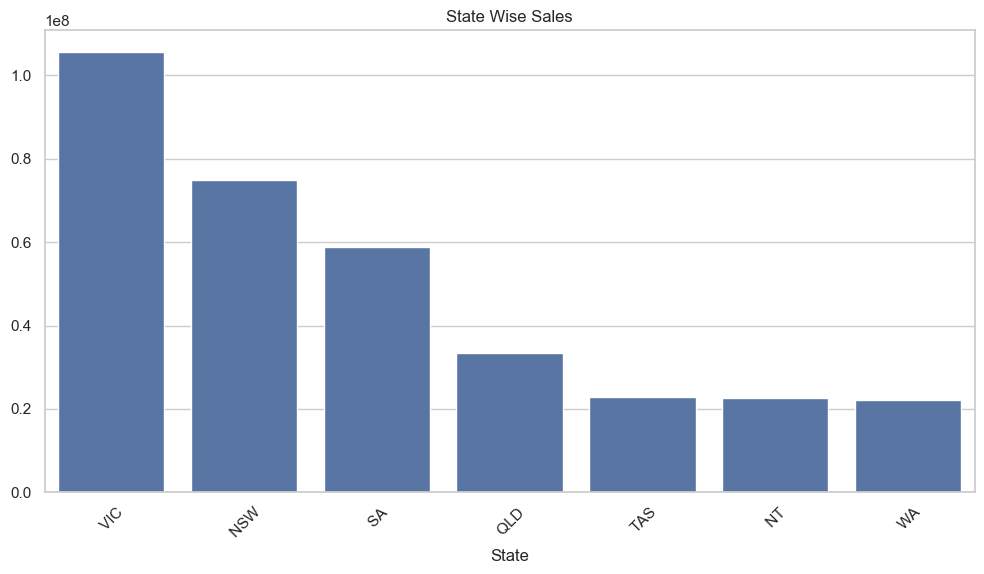

In [29]:
# Dashboard Visualization

# State-wise Sales
sns.barplot(x=state_sales.index, y=state_sales.values)
plt.title("State Wise Sales")
plt.xticks(rotation=45)
plt.show()

### State-wise Sales Dashboard
The state-wise bar plot visualizes which regions contribute the most sales and where the company should focus growth efforts.

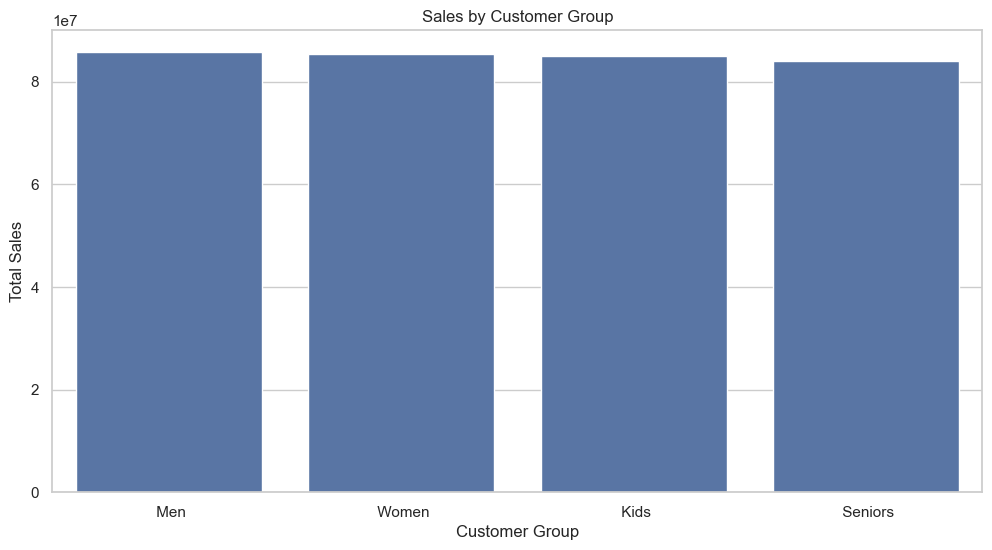

In [32]:
# Group-wise Sales
sns.barplot(x=group_sales.index, y=group_sales.values)
plt.title("Sales by Customer Group")
plt.xlabel("Customer Group")
plt.ylabel("Total Sales")
plt.show()

### Customer Group Dashboard
This visualization compares sales volume across customer groups, making demographic-driven strategy easier to plan.

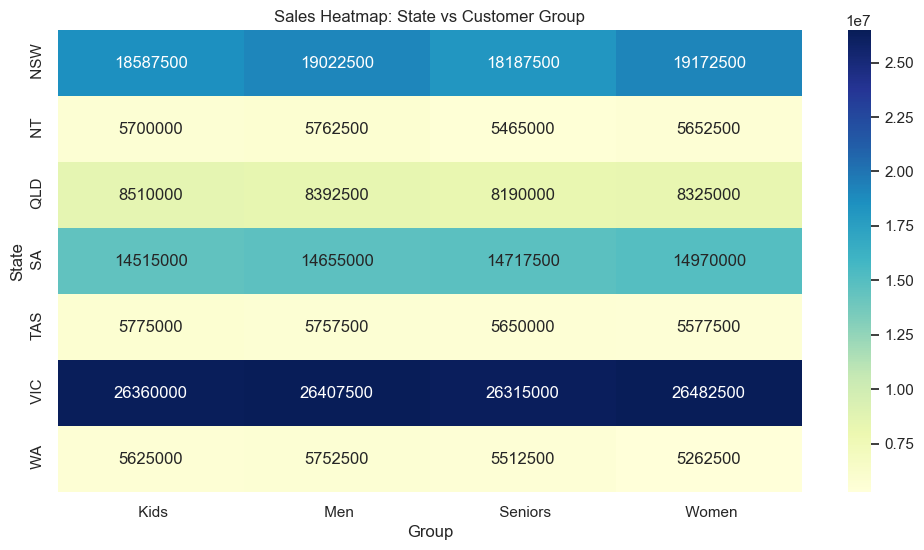

In [33]:
# State vs Group Heatmap
state_group_sales = df.pivot_table(values='Sales', index='State', columns='Group', aggfunc='sum')
sns.heatmap(state_group_sales, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Sales Heatmap: State vs Customer Group")
plt.show()

### State vs Group Heatmap
This heatmap reveals how each customer group performs in each state, supporting targeted marketing and stocking decisions.

C:\Users\apoor\AppData\Local\Temp\ipykernel_38792\3202130883.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_units.index, y=hourly_units.values, palette='viridis')


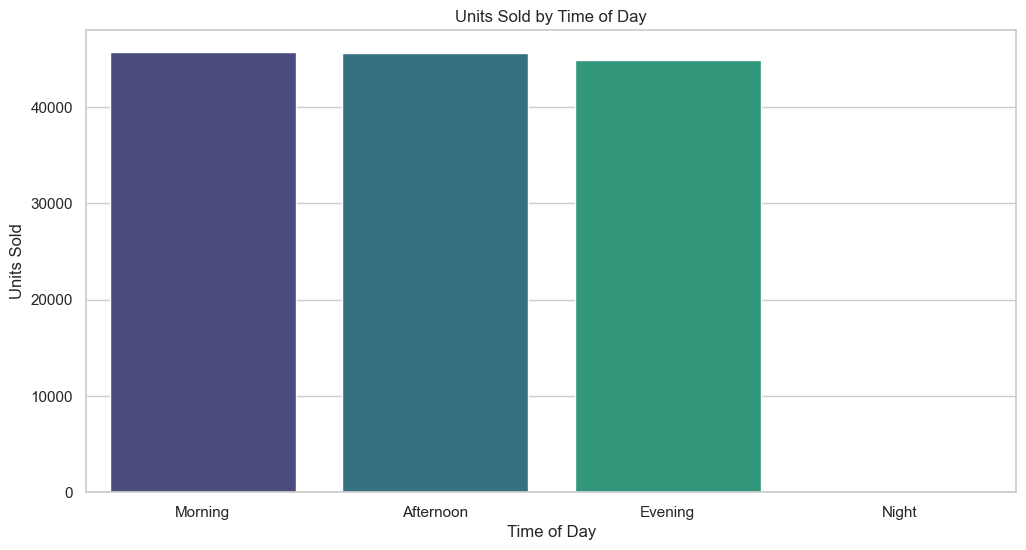

In [44]:
# Units sold by Time-of-Day Trends

df['TimeOfDay'] = df['Time'].str.strip().str.title()

hourly_units = df.groupby('TimeOfDay')['Unit'].sum().reindex(['Morning', 'Afternoon', 'Evening', 'Night']).fillna(0)

sns.barplot(x=hourly_units.index, y=hourly_units.values, palette='viridis')
plt.title("Units Sold by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Units Sold")
plt.show()

### Time-of-Day Units Sold
This chart shows units sold by time of day, helping identify peak and off-peak periods for promotions.

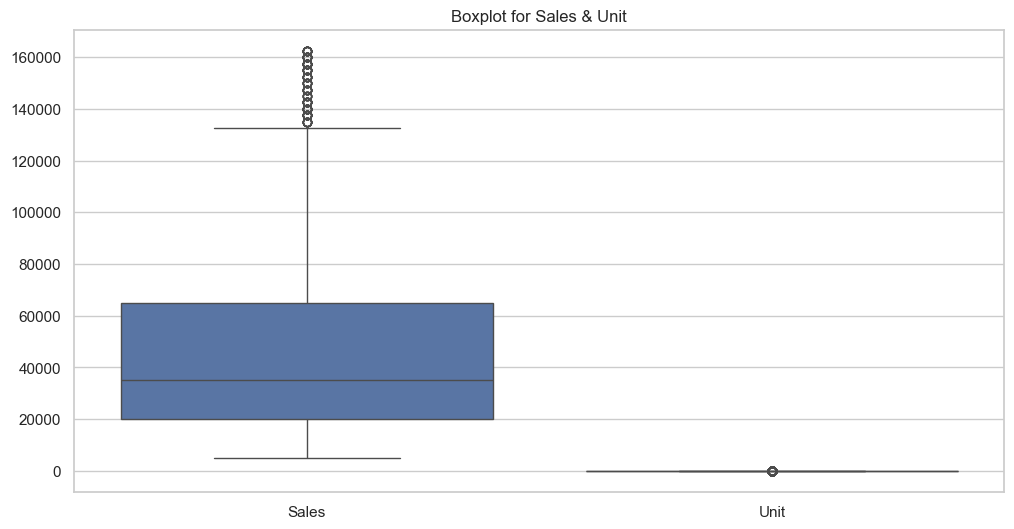

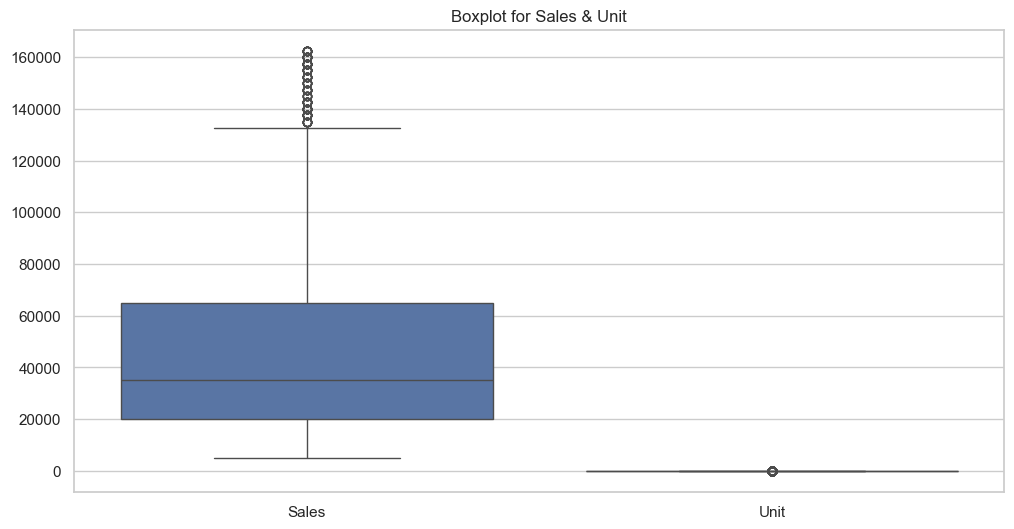

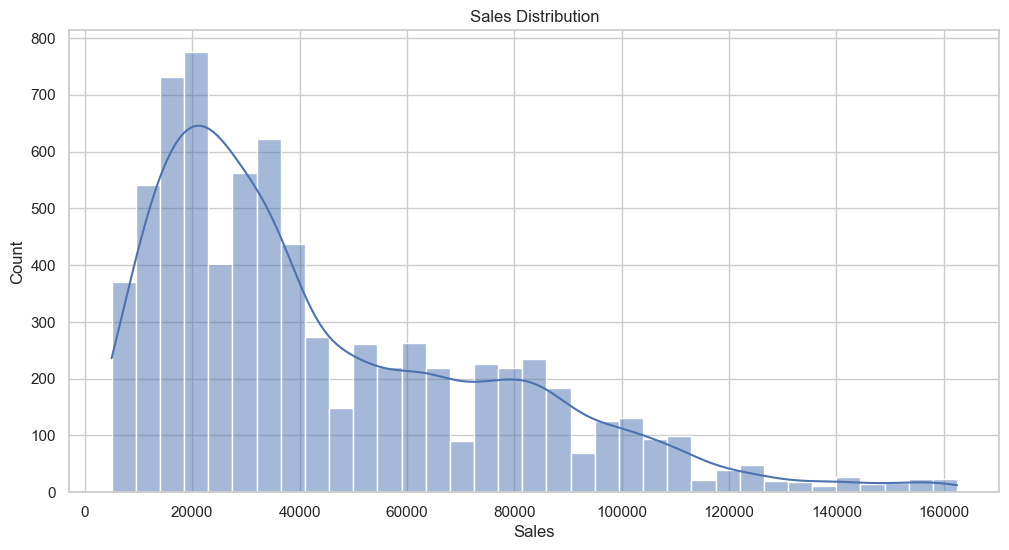

In [43]:
# Boxplot for Sales and Units
sns.boxplot(data=df[['Sales','Unit']])
plt.title("Boxplot for Sales & Unit")
plt.show()

# Distribution Plot for Sales and Units
sns.histplot(df['Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()

### Statistical Distribution and Descriptive Analysis
The box plot summarizes Sales and Unit distributions, while the Seaborn distribution plot shows Sales spread and density.

# Recomendations
# High Revenue States
    Focus on inventory expansion
    Launch premium product lines
    Increase marketing spend
# Low Revenue States
    Run discount campaigns
    Introduce regional personalization
    Improve distribution channels
# Customer Group Insights
    Identify top-performing segment
    Target underperforming segments with:
    Bundles
    Loyalty programs
# Time-Based Strategy
    Peak hours → push premium offers
    Off-peak → run discount campaigns

# Seaborn Chosen because:
    Built on Matplotlib → more powerful
    Better statistical visualization
    Easy heatmaps, distributions, boxplots
    Cleaner and more professional visuals